In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr

import confidence_intervals

In [12]:
cattaneo_data = pd.read_stata('data/cattaneo2.dta')
pd.set_option('display.max_columns', None)

In [13]:
cattaneo_smoker = cattaneo_data[cattaneo_data['mbsmoke'] == 'smoker']
cattaneo_non_smoker = cattaneo_data[cattaneo_data['mbsmoke'] == 'nonsmoker']

In [14]:
smoker_bweight = []
for index, row in cattaneo_smoker.iterrows():
  smoker_bweight.append(row['bweight'])
print(np.std(smoker_bweight))

non_smoker_bweight = []
for index, row in cattaneo_non_smoker.iterrows():
  non_smoker_bweight.append(row['bweight'])
print(np.std(non_smoker_bweight))

smoker_bweight_missing = np.append(smoker_bweight, np.ones(len(non_smoker_bweight)) * np.nan)
non_smoker_bweight_missing = np.append(non_smoker_bweight, np.ones(len(smoker_bweight)) * np.nan)

560.5683664552373
570.6115756518803


In [22]:
# print("Sub-Gaussian intervals with sub-Gaussian constant 100")
# print("Sub-Gaussian average earning winner: {}".format(confidence_intervals.adaptive_CI_subG(smoker_bweight_missing, 0.05, 100)))
# print("Sub-Gaussian average earning control: {}".format(confidence_intervals.adaptive_CI_subG(non_smoker_bweight_missing, 0.05, 100)))

# print("Symmetric interval average earning winner: {}".format(confidence_intervals.adaptive_CI_sym(smoker_bweight_missing, 0.05)))
# print("Symmetric interval average earning control: {}".format(confidence_intervals.adaptive_CI_sym(non_smoker_bweight_missing, 0.05)))

CI_smoker = confidence_intervals.adaptive_CI_Gaussian(smoker_bweight_missing, 1, 1, 0.05, 560.6)
CI_non_smoker = confidence_intervals.adaptive_CI_Gaussian(non_smoker_bweight_missing, 1, 1, 0.05, 570.6)
print(
    f"Gaussian ATE: "
    f"{CI_non_smoker['left'] - CI_smoker['right']}, "
    f"{CI_non_smoker['right'] - CI_smoker['left']}"
)


Gaussian ATE: -640.9841451948232, 1208.9841451948232


In [26]:
np.sum(np.isnan(smoker_bweight_missing))

np.int64(3778)

In [24]:
non_smoker_bweight_missing

array([3459., 3260., 3572., ...,   nan,   nan,   nan], shape=(4642,))

In [27]:
4642-3778

864

(array([  5.,   6.,   5.,  25., 113., 266., 305., 115.,  21.,   3.]),
 array([ 397. ,  859.1, 1321.2, 1783.3, 2245.4, 2707.5, 3169.6, 3631.7,
        4093.8, 4555.9, 5018. ]),
 <BarContainer object of 10 artists>)

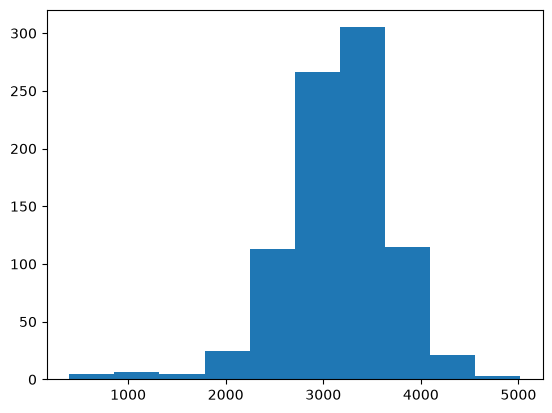

In [16]:
plt.hist(smoker_bweight)

(array([  15.,   17.,   23.,   90.,  427., 1322., 1331.,  468.,   81.,
           4.]),
 array([ 340.,  856., 1372., 1888., 2404., 2920., 3436., 3952., 4468.,
        4984., 5500.]),
 <BarContainer object of 10 artists>)

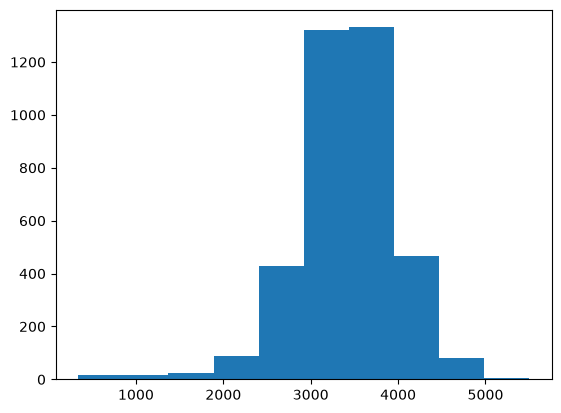

In [17]:
plt.hist(non_smoker_bweight)